# 01 · Datos: del DICOM al NIfTI con SUV

Este cuaderno recorre el Paso 1 completo. Primero con un fantoma sintético, que
funciona en cualquier computador sin descargar nada, y después con estudios reales
de autoPET si ya están en `data/raw`.

La idea del paso, en una frase: el scanner entrega cientos de archivos DICOM por
estudio, con los píxeles y una ficha de metadatos cada uno; nosotros necesitamos
cinco volúmenes limpios por estudio (CT, PET, SUV, CTres, SEG) en un formato que las
librerías de aprendizaje profundo entiendan (NIfTI). Las funciones que hacen el
trabajo viven en `src/petct/`; aquí se llaman y se explican.

In [1]:
import sys, tempfile
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
sys.path.insert(0, str(RAIZ / "tests"))
from petct.suv import SUVParams, parse_dicom_time, suv_params_from_dataset
from petct.convert import convert_study, read_dicom_series
import synthetic
print("raíz del proyecto:", RAIZ)

raíz del proyecto: /home/claude/repo


## 1. El SUV a mano

Antes de tocar archivos conviene entender el número que vamos a calcular miles de
veces. El scanner mide actividad en becquerel por mililitro. El SUV divide esa
actividad por la que habría si la dosis inyectada se hubiera repartido de manera
uniforme en todo el cuerpo (dosis dividida por peso). La analogía que uso: un frasco
de tinta en una piscina; el SUV dice cuántas veces más concentrada está la tinta en
un rincón respecto del promedio de la piscina.

Hay un detalle que se olvida fácil: entre la inyección y el scan pasa casi una hora,
y el flúor 18 pierde la mitad de su actividad cada 109,8 minutos. La dosis que se usa
en el denominador es la que queda en el cuerpo al momento del scan, no la que se
inyectó. Veamos los números con un caso típico.

In [2]:
p = SUVParams(weight_kg=70.0, injected_dose_bq=300e6, half_life_s=6586.2,
              injection_time=parse_dicom_time("100000"), scan_time=parse_dicom_time("110000"))
print(f"tiempo entre inyección y scan: {p.decay_time_s/60:.0f} min")
print(f"fracción de dosis que queda:   {p.decayed_dose_bq / p.injected_dose_bq:.3f}")
print(f"dosis corregida:               {p.decayed_dose_bq/1e6:.1f} MBq")
print(f"factor SUV (multiplica Bq/mL): {p.scale_factor:.6f}")
print(f"un vóxel con 3000 Bq/mL tiene SUV = {3000 * p.scale_factor:.2f}")

tiempo entre inyección y scan: 60 min
fracción de dosis que queda:   0.685
dosis corregida:               205.4 MBq
factor SUV (multiplica Bq/mL): 0.000341
un vóxel con 3000 Bq/mL tiene SUV = 1.02


Ese último número es el que importa clínicamente: 3000 Bq/mL en este paciente
equivale a SUV cerca de 1, es decir, captación promedio. Una lesión con SUV 8 tiene
ocho veces esa concentración.

## 2. Un fantoma para probar sin datos reales

`tests/synthetic.py` fabrica un estudio DICOM completo: un cuerpo elíptico de agua,
una esfera caliente de SUV 8 sobre fondo de SUV 1, un CT a 2 mm y un PET a 4 mm (a
propósito con distinta resolución, como en la realidad), y un DICOM SEG con los
cortes guardados en orden inverso para comprobar que la conversión usa la posición
física de cada corte y no su orden en el archivo. Es el mismo papel que cumple el
fantoma de control de calidad del PET: un objeto con respuesta conocida.

In [3]:
raiz_fantoma = Path(tempfile.mkdtemp(prefix="fantoma_"))
verdad = synthetic.make_phantom(raiz_fantoma)
for carpeta in ("CT", "PT", "SEG"):
    n = len(list((raiz_fantoma / carpeta).glob("*.dcm")))
    print(f"{carpeta}: {n} archivos DICOM")

CT: 20 archivos DICOM
PT: 20 archivos DICOM
SEG: 1 archivos DICOM


## 3. Leer los metadatos del PET y calcular el factor

`suv_params_from_dataset` abre la ficha DICOM de una lámina PET y saca de ahí el
peso, la dosis, la semivida y las dos horas. Si alguna etiqueta falta, o las
unidades no son Bq/mL, la función se detiene con un error en vez de seguir con un
SUV inventado. Ese comportamiento es deliberado: un estudio sin SUV confiable no
sirve para el proyecto y se registra en `errores_conversion.csv`.

In [4]:
import pydicom
primera = sorted((raiz_fantoma / "PT").glob("*.dcm"))[0]
ds = pydicom.dcmread(primera, stop_before_pixels=True)
print("Units:", ds.Units, "| DecayCorrection:", ds.DecayCorrection, "| peso:", ds.PatientWeight, "kg")
params = suv_params_from_dataset(ds)
print(f"factor leído del DICOM: {params.scale_factor:.6f}")
print(f"factor esperado:        {verdad['suv_factor']:.6f}")

Units: BQML | DecayCorrection: START | peso: 70.0 kg
factor leído del DICOM: 0.000341
factor esperado:        0.000341


## 4. Convertir el estudio completo

`convert_study` hace todo el trabajo: lee las tres series, escribe CT y PET, aplica el
factor para obtener SUV, remuestrea el CT sobre la grilla del PET (CTres) y convierte
el SEG a máscara. CTres merece una explicación. El CT tiene vóxeles de 2 mm y el PET
de 4 mm en este fantoma (en autoPET, cerca de 1 mm contra 2 mm). La red necesita dos
tensores del mismo tamaño y alineados vóxel a vóxel, así que el CT se "vuelve a
fotografiar" con la cámara del PET: para cada vóxel del PET se calcula el valor de CT
en esa misma posición física por interpolación lineal. Se pierde detalle del CT, pero
se gana lo único que la red puede usar: correspondencia exacta.

In [5]:
salidas = convert_study(raiz_fantoma, raiz_fantoma / "nifti")
for nombre, ruta in salidas.items():
    img = sitk.ReadImage(str(ruta))
    print(f"{nombre:6s} tamaño (x,y,z) = {img.GetSize()}  espaciado = {tuple(round(s,2) for s in img.GetSpacing())} mm")

CT     tamaño (x,y,z) = (64, 64, 20)  espaciado = (2.0, 2.0, 2.0) mm
PET    tamaño (x,y,z) = (32, 32, 20)  espaciado = (4.0, 4.0, 2.0) mm
SUV    tamaño (x,y,z) = (32, 32, 20)  espaciado = (4.0, 4.0, 2.0) mm
CTres  tamaño (x,y,z) = (32, 32, 20)  espaciado = (4.0, 4.0, 2.0) mm
SEG    tamaño (x,y,z) = (32, 32, 20)  espaciado = (4.0, 4.0, 2.0) mm


CT quedó en 64 × 64 y CTres en 32 × 32, la grilla del PET. Ahora la verificación
visual y numérica, que es lo que uno haría con un estudio real en 3D Slicer.

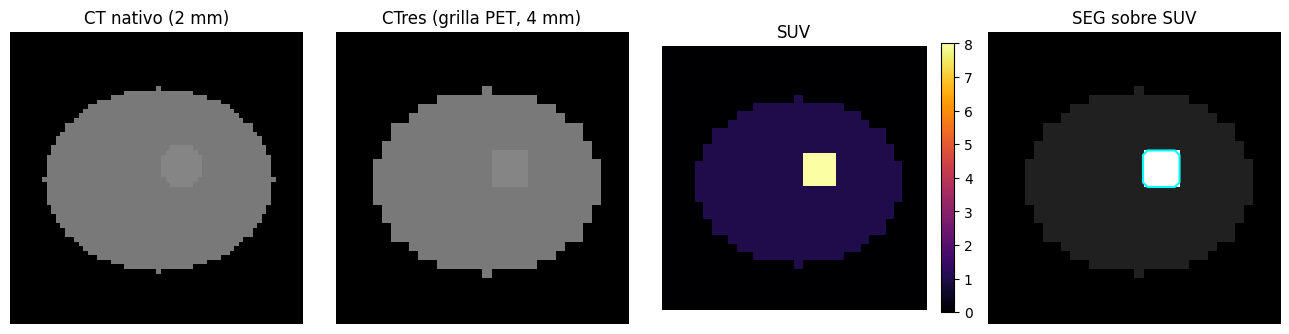

SUV mediana en lesión: 8.00   en fondo: 1.00
Dice entre SEG convertido y verdad: 1.0000


In [6]:
ct = sitk.GetArrayFromImage(sitk.ReadImage(str(salidas["CT"])))
ctres = sitk.GetArrayFromImage(sitk.ReadImage(str(salidas["CTres"])))
suv = sitk.GetArrayFromImage(sitk.ReadImage(str(salidas["SUV"])))
seg = sitk.GetArrayFromImage(sitk.ReadImage(str(salidas["SEG"])))
z = 10
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
ax[0].imshow(ct[z], cmap="gray", vmin=-200, vmax=300); ax[0].set_title("CT nativo (2 mm)")
ax[1].imshow(ctres[z], cmap="gray", vmin=-200, vmax=300); ax[1].set_title("CTres (grilla PET, 4 mm)")
im = ax[2].imshow(suv[z], cmap="inferno", vmin=0, vmax=8); ax[2].set_title("SUV"); plt.colorbar(im, ax=ax[2], fraction=0.046)
ax[3].imshow(suv[z], cmap="gray", vmin=0, vmax=8); ax[3].contour(seg[z], levels=[0.5], colors="cyan"); ax[3].set_title("SEG sobre SUV")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

lesion = verdad["lesion_pet"]; fondo = verdad["body_pet"] & ~lesion
print(f"SUV mediana en lesión: {np.median(suv[lesion]):.2f}   en fondo: {np.median(suv[fondo]):.2f}")
inter = (seg.astype(bool) & lesion).sum()
print(f"Dice entre SEG convertido y verdad: {2*inter/(seg.sum()+lesion.sum()):.4f}")

Los tres números que hay que mirar: lesión cerca de 8, fondo cerca de 1, Dice cerca
de 1. Si alguno falla con un estudio real, el problema está en las etiquetas del
DICOM (unidades, horas) o en la geometría del SEG, y ahí hay que detenerse.

## 5. Con estudios reales de autoPET

Esta sección solo corre si ya ejecutaste `scripts/02_descargar_tcia.py` en tu
computador (la API de TCIA no es alcanzable desde todos los entornos). Convierte los
estudios que encuentre en `data/raw` usando la tabla `data/manifests/series_tcia.csv`
y muestra el primero. Con datos reales los valores esperables son: fondo hepático SUV
2 a 3, encéfalo SUV 6 a 10, vejiga a veces sobre 30, y las lesiones anotadas dentro
de zonas calientes del PET.

In [7]:
import pandas as pd, os
series_csv = RAIZ / "data/manifests/series_tcia.csv"
raw = RAIZ / "data/raw"
if series_csv.exists() and any(raw.iterdir()):
    series = pd.read_csv(series_csv)
    print(series.groupby("Modality").size())
    # convertir con el script (agrupa por estudio y maneja errores)
    !python {RAIZ}/scripts/03_convertir_a_nifti.py --raw {raw} --series-csv {series_csv} --out {RAIZ}/data/interim/nifti
else:
    print("Todavía no hay datos reales en data/raw. Corre scripts/01 y 02 en tu computador y vuelve aquí.")

Todavía no hay datos reales en data/raw. Corre scripts/01 y 02 en tu computador y vuelve aquí.


In [8]:
nifti = RAIZ / "data/interim/nifti"
estudios = sorted(nifti.glob("*/*/SUV.nii.gz"))
if estudios:
    carpeta = estudios[0].parent
    suv = sitk.GetArrayFromImage(sitk.ReadImage(str(carpeta / "SUV.nii.gz")))
    seg = sitk.GetArrayFromImage(sitk.ReadImage(str(carpeta / "SEG.nii.gz")))
    ctres = sitk.GetArrayFromImage(sitk.ReadImage(str(carpeta / "CTres.nii.gz")))
    print("estudio:", carpeta.relative_to(nifti), "| forma (z,y,x):", suv.shape)
    print(f"SUV máximo: {suv.max():.1f}  | vóxeles de lesión: {int(seg.sum())}  | volumen ≈ {seg.sum()*np.prod(sitk.ReadImage(str(carpeta/'SUV.nii.gz')).GetSpacing())/1000:.1f} mL")
    # proyección de intensidad máxima (MIP) coronal: la "foto" clásica del PET
    mip = suv.max(axis=1)
    fig, ax = plt.subplots(1, 2, figsize=(8, 8))
    ax[0].imshow(np.flipud(mip), cmap="gray_r", vmin=0, vmax=8, aspect="auto"); ax[0].set_title("MIP coronal SUV")
    ax[1].imshow(np.flipud(mip), cmap="gray_r", vmin=0, vmax=8, aspect="auto")
    ax[1].contour(np.flipud(seg.max(axis=1)), levels=[0.5], colors="red"); ax[1].set_title("lesiones anotadas")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Sin estudios convertidos aún.")

Sin estudios convertidos aún.


## Qué registrar en la bitácora al terminar

Cuántos estudios se convirtieron y cuántos fallaron (y por qué), el rango de SUV
máximo que viste, si las lesiones anotadas coinciden con las zonas calientes en el
MIP, y cualquier decisión que hayas tomado (por ejemplo, excluir un estudio con
etiquetas incompletas). Con eso el Paso 1 queda cerrado y se abre el Paso 2.